In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

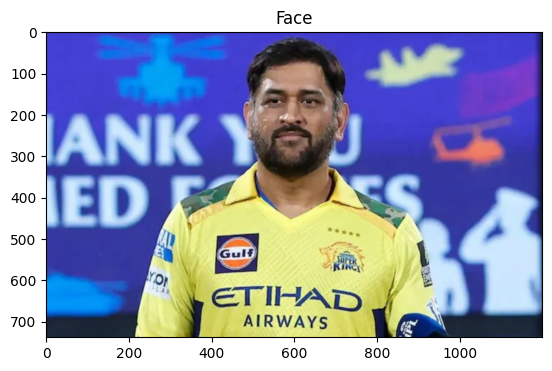

In [2]:
# Load the Face Image
faceImage = cv2.imread('IMAGE.webp')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(531, 413, 3)

In [5]:
#resized_faceImage.shape
faceImage.shape

(531, 413, 3)

Text(0.5, 1.0, 'glassPNG')

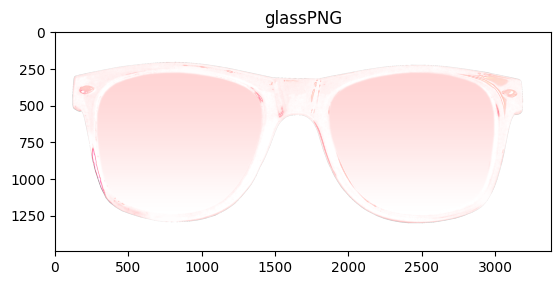

In [13]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('SUNGLASS.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [14]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [15]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

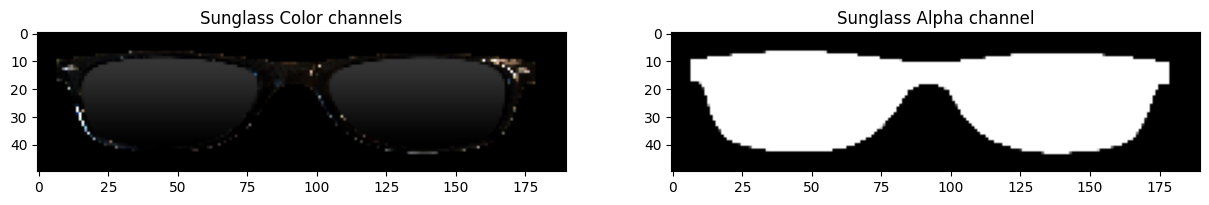

In [16]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

(np.float64(-0.5), np.float64(1199.5), np.float64(737.5), np.float64(-0.5))

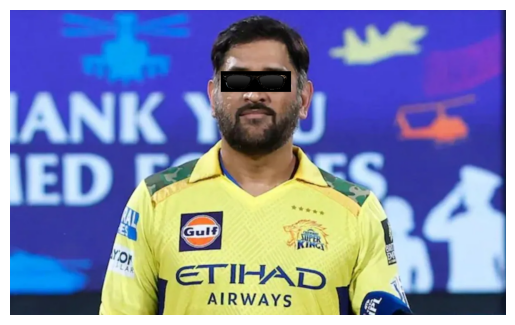

In [26]:
# Make a copy
faceWithGlassesNaive = faceImage.copy()

# Resize sunglasses (fit properly to eye width)
glass_resized = cv2.resize(glassBGR, (170, 50))

# Exact eye placement (fine-tuned)
faceWithGlassesNaive[150:200, 510:680] = glass_resized

plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.axis('off')

(np.float64(-0.5), np.float64(1199.5), np.float64(737.5), np.float64(-0.5))

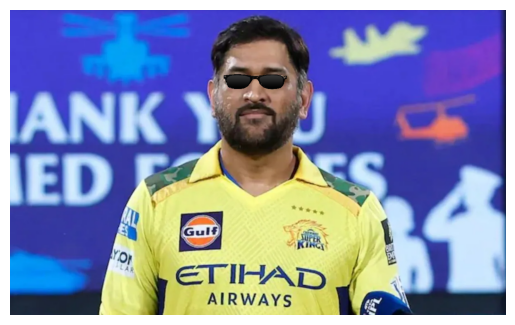

In [29]:
# Resize mask to match sunglasses size used for this face
glass_resized = cv2.resize(glassBGR, (170, 50))
glassMask1_resized = cv2.resize(glassMask1, (170, 50))

# Make the mask 3-channel
glassMask = cv2.merge((glassMask1_resized, glassMask1_resized, glassMask1_resized))

# Normalize mask to [0,1]
glassMask = np.uint8(glassMask / 255)

# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Updated eye region (aligned to your image)
eyeROI = faceWithGlassesArithmetic[150:200, 510:680]

# Resize sunglasses to match ROI
glass_resized = cv2.resize(glassBGR, (170, 50))

# Apply masking
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glass_resized, glassMask)

# Combine
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Place back into image
faceWithGlassesArithmetic[150:200, 510:680] = eyeRoiFinal

# Show result
plt.imshow(faceWithGlassesArithmetic[..., ::-1])
plt.axis('off')

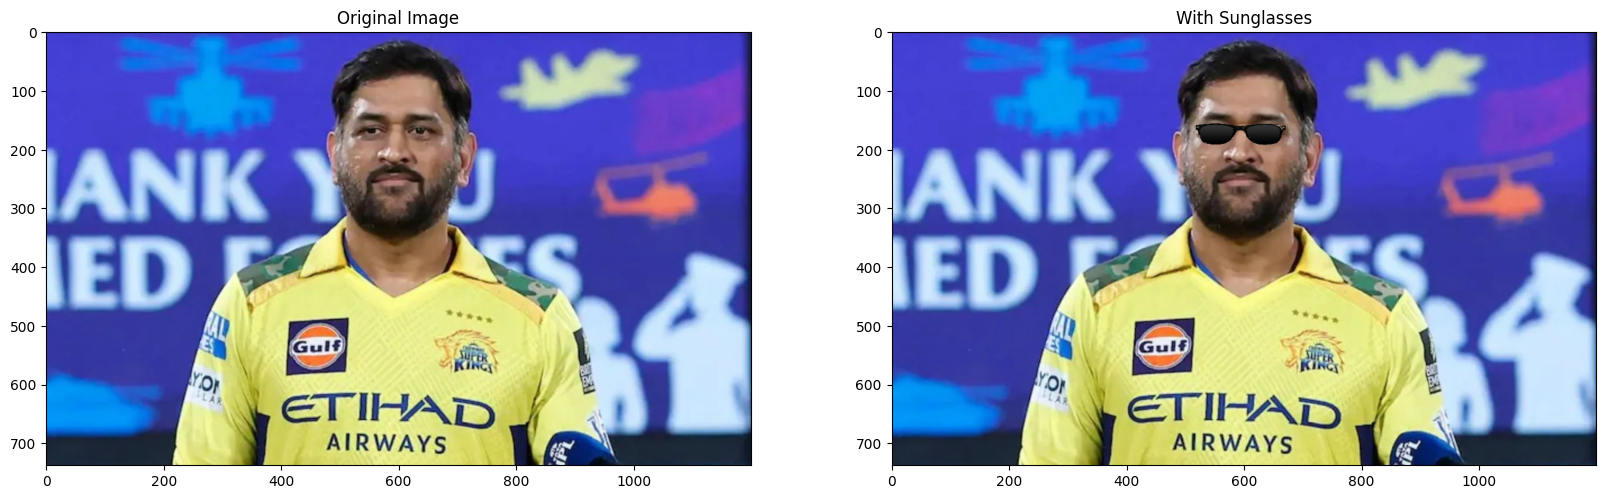

In [30]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[150:200, 510:680]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");